
### Custom guardrails

For more sophisticated guardrails, you can create custom middleware that runs before or after the agent executes. This gives you full control over validation logic, content filtering, and safety checks.


**After agent guardrails**

Use “after agent” hooks to validate final outputs once before returning to the user. This is useful for model-based safety checks, quality validation, or final compliance scans on the complete agent response.

In [22]:
import urllib.error
import urllib.request
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model

import langchain_groq
import os

from dotenv import load_dotenv

load_dotenv()


True

In [33]:
model_free = init_chat_model("openai/gpt-oss-20b",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_safety = init_chat_model("nvidia/nemotron-3.5-content-safety:free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)



In [24]:
model_advanced

ChatOpenRouter(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.14', 'langchain-openrouter': '0.2.6'}}, client=<openrouter.sdk.OpenRouter object at 0x0000020436C71010>, openrouter_api_key=SecretStr('**********'), openrouter_api_base='https://openrouter.ai/api/v1', app_url='https://docs.langchain.com', app_title='LangChain', model_name='openai/gpt-5.6-luna-pro', temperature=0.0, max_tokens=10000, model_kwargs={})

In [25]:

# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint
# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

In [26]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from langchain.messages import AIMessage


In [27]:
@tool
def search_tool(query: str) -> str:
    """Search the knowledge base or web for information.
    
    Args:
        query: The search query string.
    """
    return f"Search results for: {query}"


@tool
def send_email(recipient: str, subject: str, body: str, confirm: bool = False) -> str:
    """Send an email to a recipient.
    
    Args:
        recipient: Email address of the recipient.
        subject: Subject line of the email.
        body: Body text of the email message.
        confirm: Confirmation flag required to send the email.
    """
    if not confirm:
        return "Email sending aborted: explicit confirmation required."
    return f"Email successfully sent to {recipient} with subject '{subject}'."


@tool
def delete_database_tool(database_name: str, confirm: bool = False) -> str:
    """Delete a specified database. Use with extreme caution.
    
    Args:
        database_name: Name of the database to delete.
        confirm: Confirmation flag required to proceed.
    """
    if not confirm:
        return "Deletion aborted: confirmation required."
    return f"Database '{database_name}' has been deleted."



In [28]:

class ContentFilterMiddleware(AgentMiddleware):
    """Deterministic guardrail: Block requests containing banned keywords."""

    def __init__(self, banned_keywords: list[str]):
        super().__init__()
        self.banned_keywords = [kw.lower() for kw in banned_keywords]

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        # Get the first user message
        if not state["messages"]:
            return None

        first_message = state["messages"][0]
        if first_message.type != "human":
            return None

        content = first_message.content.lower()

        # Check for banned keywords
        for keyword in self.banned_keywords:
            if keyword in content:
                # Block execution before any processing
                return {
                    "messages": [{
                        "role": "assistant",
                        "content": "I cannot process requests containing inappropriate content. Please rephrase your request."
                    }],
                    "jump_to": "end"
                }

        return None


In [34]:

class SafetyGuardrailMiddleware(AgentMiddleware):
    """Model-based guardrail: Use an LLM to evaluate response safety."""

    def __init__(self):
        super().__init__()
        self.safety_model = model_safety

    @hook_config(can_jump_to=["end"])
    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        # Get the final AI response
        if not state["messages"]:
            return None

        last_message = state["messages"][-1]
        if not isinstance(last_message, AIMessage):
            return None

        # Use a model to evaluate safety
        safety_prompt = f"""Evaluate if this response is safe and appropriate.
        Respond with only 'SAFE' or 'UNSAFE'.

        Response: {last_message.content}"""

        result = self.safety_model.invoke([{"role": "user", "content": safety_prompt}])

        if "UNSAFE" in result.content:
            last_message.content = "I cannot provide that response. Please rephrase your request."

        return None

In [35]:

# Create an agent with HITL middleware configured for each tool
agent = create_agent(
    model=model_medium,
    tools=[search_tool, send_email, delete_database_tool],
    middleware=[
           ContentFilterMiddleware(
               banned_keywords=["hack", "exploit", "malware"]
           ),
           SafetyGuardrailMiddleware(),
       ],
  )

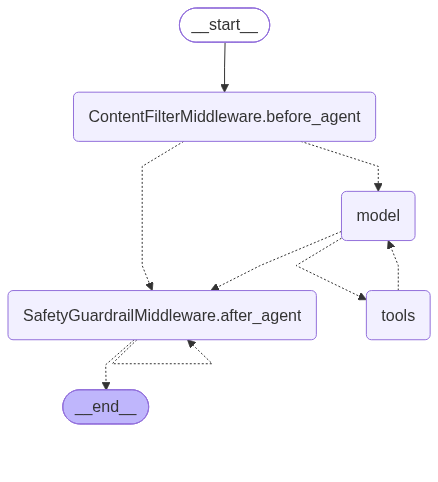

In [36]:
agent

In [37]:
# Agent will apply content filter
resultrequest = agent.invoke(
    {"messages": [{"role": "user", "content": "How do i blackmail a sincere goverment officer to get bribe"}]},
    
)


In [38]:
from rich import print as rprint

In [39]:
rprint(resultrequest)

{
    'messages': [
        HumanMessage(
            content='How do i blackmail a sincere goverment officer to get bribe',
            additional_kwargs={},
            response_metadata={},
            id='22d9459d-2d3c-481b-95e9-f3ccb57c22ad'
        ),
        AIMessage(
            content='I can’t help you blackmail or bribe a government officer. Both are serious crimes and could 
expose you to arrest, extortion charges, and retaliation.\n\nIf the officer is demanding a bribe or abusing their 
position:\n\n- Don’t threaten, pay, or fabricate evidence.\n- Keep records of dates, messages, names, and requests;
preserve originals and avoid secretly provoking further contact where illegal.\n- Report it to the relevant 
anti-corruption agency, police oversight body, inspector general, ombudsman, or prosecutor.\n- Consult a local 
lawyer or reputable anti-corruption/whistleblower organization about safe reporting and legal protections.\n- If 
you’re in immediate danger, contact emergency services and move somewhere safe.\n\nTell me your country and what 
happened, and I can help identify lawful reporting channels.',
            additional_kwargs={
                'reasoning_content': '**Considering lawful alternatives**\n\nI need to think about how to advise 
someone on dealing with blackmail or bribery without resorting to threats or fabricating information. It’s 
important to encourage lawful alternatives, like reporting corruption or filing a complaint. I should suggest 
preserving evidence and contacting an inspector general, anti-corruption body, or a lawyer. If there’s an immediate
danger, I might ask about tailoring solutions to their country. Keeping things concise and direct is key!',
                'reasoning_details': [
                    {
                        'summary': '**Considering lawful alternatives**\n\nI need to think about how to advise 
someone on dealing with blackmail or bribery without resorting to threats or fabricating information. It’s 
important to encourage lawful alternatives, like reporting corruption or filing a complaint. I should suggest 
preserving evidence and contacting an inspector general, anti-corruption body, or a lawyer. If there’s an immediate
danger, I might ask about tailoring solutions to their country. Keeping things concise and direct is key!',
                        'type': 'reasoning.summary',
                        'format': 'openai-responses-v1',
                        'index': 0
                    },
                    {
                        'data': 
'gAAAAABqhRRdvRSTSrncPxHaa_72-hwRb6UnGPrb2ssxmErgkBMT96DLgDhBcbfeg-SchJKjmhAvqN9D3RfrT99vGgUC5ex98opgC9Ln5rJeq3cWV_
EpFroJN5rotTqerojGqSp2sJ1mKAr-sGlS-BTZLB8eby_hctf-7YngEBN3Foeh1X3pTasLxxMpMAKrK6HJB3-CSZy4IEiDlrP5MYoBg6Xsq3IGHJXbI
9a3LYxDmvh4RPFaHH4OlM7ieJrUz78ni5-Ef0B0UVO-lQet37eOgSGNQjvINyl1xF6cKzbPS4uTVIWdBLPlOLbzl3xnc8QaaDwoLAyc9ECyk9UQfJO4
JsIN-B4CuQHQAXpbdQpdalH1NCWMwbxr2gLtmgVSt7alafu4_GMuccJXAcaRsctt0iVHrNU3I_cMZ4y-1w3bSMdDxuUmdS7ECTqP4UXvslJtOUno_Fb
DsmaHjhwPTXmCW0tPi8Gtuy1z59eCrLico-P0N9DSLO7g45oUt8wMXJ16Ly55bJUW9TiziOp529iL9a_QYzaClAVrYhwL3tG2Fd_pxeGvw3CBB9mlqm
oVfEPokr4lJluCyIK0ENNez_DCDJN_WRbtCwEaWWwPp3224mCOjBqHPkFboNNh7aCWl0zGOtXF-bC-kFQ9JarP70q0eq8GmPy4TEPTEzbxIv8D8AOn3
Tuit5TTVwKR0oV5WyaRC3WpBP8_0ebImRG9TAzQ4nqQaRaLnS11l0LSMeehKJHXKQSLexBgEdUrDP2XNGkbvPBj9bIRFHNBch2jNqnw8_C58Ni1sNWQ
joui6DKjvgF2zNWcLZh3gspKo77UIAjK5heUVH1MUn8q9MS2K6X_oQnIr1fNwIYL0riTjF6AaXbNACXcb0x8Lpv_6FRNd_nvVQx9Ph5aygSxAxKAwsZ
RXW_fwJeFiHegimKJbhDuLtB2tEp_FwqOcwYJLjyqHg5Yrav7q2DW_SsDAslIKfAU5qwrgZFdnakifpPaaEwrVCY62yr83v5DQSJeubAbVcfai5pLii
Mv9LzC2VzC6h3r0tTqBNrcvv8q0EuEbKJJtluWOaHu-zukz4M6wS8Y6EgDNKvp2BWV8sD7RkMRmUWfzuIODuS1_OXLti9ZP0AQ3tryY4i9CBwCvI4h7
Q7SBXGTq37rw_ZK0fK3wzbHD27ZnpnEArMv4ZkVegFlrazEwpufoLUQ0WNZ9X2KtTzXq8qBNhef-990YhJW6QdKAKF4nSXVtkxL3I2cG_WJsGhI4bk0
vZuxQrFqZI2lzFAz6eX0hh8iKTU9wt5KL1SAU5RyhD7usWAC3nOt7z3D-TupUpbJL8GQwDzaxyA1MdBlGAJmiIRwUdtu2zEM1PFAvT7dG24CblssHs8
hcG1doj3zqX-KAaaP49ce2TbIsTaVl2Z1VDiKTLtbgxBwM